In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import NLCLIMB
import NLMATH
import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

DATA_DIR = r"D:\2. Processed"
WT = "w1118"

COLORS = {
    "ACR":   {"dark": "#1AB80B", "light": "#7BBB14", "patch": "#cde49d"},
    "OPN3": {"dark": "#07527A", "light": "#42B6DA", "patch": "#cde49d"},
    "PdCO":  {"dark": "#9452FF", "light": "#b675f3", "patch": "#7abdff"},
}

In [ ]:
def trim_to_22s(df):
    df = df.reset_index(drop=True)
    df["Seconds"] = round(df["Seconds"], 1)
    return df.drop(df[df["Seconds"] > 22.0].index)

def load(driver, responder):
    transgenic = f"{driver} x {responder}"
    dfe = pd.read_csv(os.path.join(DATA_DIR, f"{transgenic}.csv")).iloc[:, 1:]
    dfw = pd.read_csv(os.path.join(DATA_DIR, f"{WT}_{transgenic}.csv")).iloc[:, 1:]
    return NLCLIMB.generation(dfe, driver), NLCLIMB.generation(dfw, WT)

def mean_ci(df, pattern):
    return trim_to_22s(NLMATH.meangraph(NLMATH.calcgraph(df, pattern)))

def get_colors(responder):
    has_atr = "[ATR]" in responder or "[atr]" in responder
    for key, palette in COLORS.items():
        if key in responder:
            return palette["dark" if has_atr else "light"], palette["patch"]
    return "#7BBB14", "#cde49d"

def draw_trace(ax, expt, wt, state, bar_color, span_alpha, span_color, expt_label, wt_label):
    ax.axvspan(3, 23, alpha=span_alpha, color=span_color, label="_nolegend_")
    time = expt.loc[expt.ExperimentState == state, "Seconds"]
    for df, color, label in [(expt, bar_color, expt_label), (wt, "#000000", wt_label)]:
        m = df.loc[df.ExperimentState == state, "mean"]
        ci = df.loc[df.ExperimentState == state, "CI"]
        ax.plot(time, m, color=color, linewidth=2, label=label)
        ax.fill_between(time, m - ci, m + ci, color=color, alpha=.1, label="_nolegend_")

def plot(driver, responder):
    dfexpt, dfwt = load(driver, responder)
    y_expt = mean_ci(dfexpt, "Y.*")
    y_wt   = mean_ci(dfwt,   "Y.*")
    v_expt = mean_ci(dfexpt, "Velocity.*")
    v_wt   = mean_ci(dfwt,   "Velocity.*")

    bar_color, patch_color = get_colors(responder)
    name = f"{driver} x {responder}"

    fig, axs = plt.subplots(2, 2, figsize=(6, 4), sharex="col", sharey="row")

    draw_trace(axs[0, 0], y_expt, y_wt, "Dark", bar_color, 0.1, "#000000", name, "w1118 controls")
    draw_trace(axs[0, 1], y_expt, y_wt, "Full", bar_color, 0.3, patch_color, "_nolegend_", "_nolegend_")
    draw_trace(axs[1, 0], v_expt, v_wt, "Dark", bar_color, 0.1, "#000000", name, "w1118 controls")
    draw_trace(axs[1, 1], v_expt, v_wt, "Full", bar_color, 0.3, patch_color, "_nolegend_", "_nolegend_")

    axs[0, 0].set_ylim([0, 100])
    axs[0, 0].set_ylabel("Mean height (mm)", fontsize=12)
    axs[1, 0].set_ylim([0, 35])
    axs[1, 0].set_yticks(np.arange(0, 36, 10))
    axs[1, 0].set_ylabel("Mean speed (mm/s)", fontsize=12)
    axs[1, 0].set_xlabel("Time(seconds)", fontsize=16)
    axs[1, 1].set_xlabel("Time(seconds)", fontsize=16)

    for ax in axs.flat:
        ax.label_outer()
        ax.set_xlim([-1, 23])
        ax.tick_params(axis="both", labelsize=14)

    fig.tight_layout()
    mpl.rcParams["svg.fonttype"] = "none"
    plt.show()
    return fig

## Figure 3_line plots

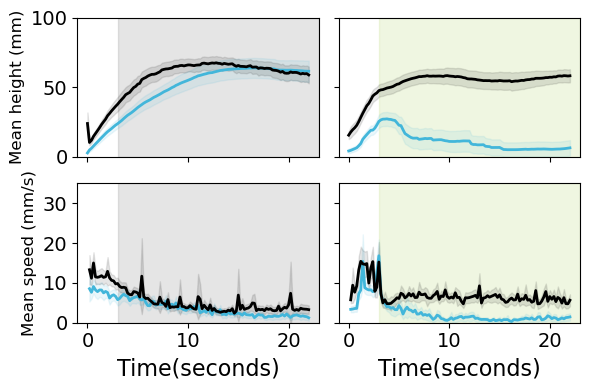

In [ ]:
plot("elav", "OPN3");

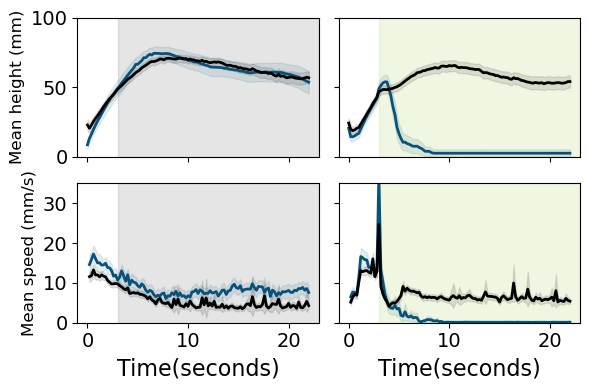

In [ ]:
plot("elav", "OPN3 [ATR]");

## Supplementary Figure 7_line plots

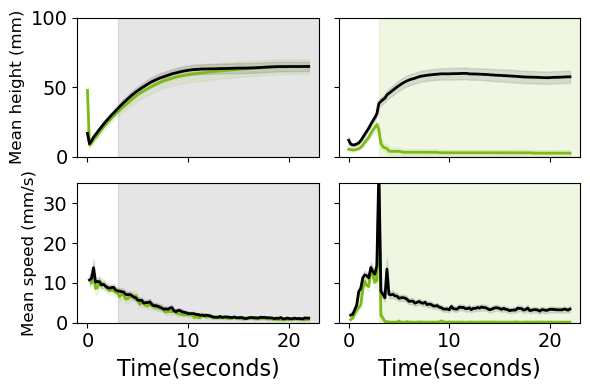

In [5]:
plot("OK371", "ACR");

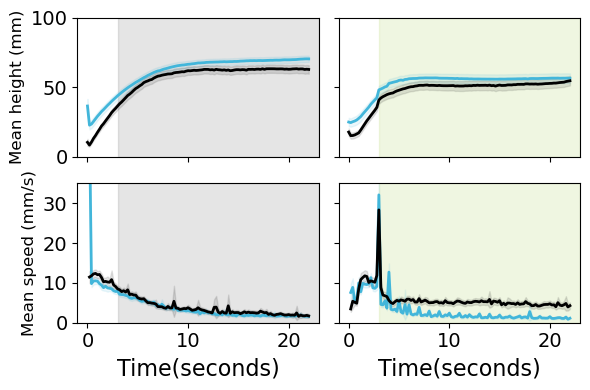

In [ ]:
plot("OK371", "OPN3");